# Imports

In [2]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Problem 1

## Part 1

Reading graph from Wikispeed

In [3]:
G = nx.read_edgelist("./Midterm_2026/wikispeedia.edgelist", create_using = nx.DiGraph)

Evaluating hits centrality

In [4]:
hubs, authorities = nx.hits(G)
hits = pd.DataFrame({'Hub' : hubs, 'Authority' : authorities})

In [5]:
print("Hub with the highest value")
hits[hits['Hub'] == hits['Hub'].max()]

Hub with the highest value


,Hub,Authority
Driving_on_the_left_or_right,0.002274,-0.0


In [6]:
print("Authority with the highest value")
hits[hits['Authority'] == hits['Authority'].max()]

Authority with the highest value


,Hub,Authority
United_States,0.001829,0.011525


## Part 2

Total number of nodes, N

In [7]:
N = G.number_of_nodes()

Creating initial state probability

In [8]:
pi0 = np.ones(N,) / N

Creating W matrix

In [9]:
def createW(G: nx.Graph, node_list, alpha: float = 0.1):

    N = G.number_of_nodes()
    W = np.zeros((N, N))

    out_degree = np.array([out for node,out in G.out_degree(node_list)])
    
    # If a node's neighborhood is empty, the entire row = 1/N
    W[out_degree == 0] = 1/N
    
    # For all rows with out_degree > 0 (non empty out neighborhoods)
    # base probability is set to alpha / N
    W[out_degree > 0] = alpha/N
    
    # The nodes actually in out-neightborhoods will recieve an additional probability boost
    A = nx.adjacency_matrix(G, node_list)
    W[out_degree > 0] += (A[out_degree > 0].T * (1 - alpha) / out_degree[out_degree > 0]).T
        
    return W


In [10]:
node_list = list(G.nodes())
alpha = 0.1
W = createW(G, node_list, alpha)

Iterating to find page rank

In [11]:
pi = pi0
pi_new = None
tol = 1E-10
max_iter = 100

for n in range(max_iter):
    pi_new = W.T @ pi
    
    if np.linalg.norm(pi_new - pi) <= tol:
        break
    
    pi = pi_new

In [12]:
calculated_pagerank = dict(zip(node_list, pi))
nx_pagerank = nx.pagerank(G, 1 - alpha)

# Problem 2

## Part 1

Creating **connected** Random Geometrix Graph

In [32]:
N = 100
radius = 0.9
G = nx.random_geometric_graph(N, radius)

## Part 2

In [ ]:
p = 0.2
seed = 2026
rng = np.random.default_rng(seed = seed)

In [37]:
def next_state(x, edgelist, rng):
    
    x_new = x.copy()
    # randomly select element from list
    gossip_edge = edgelist[rng.integers(len(edgelist))]
    u, v = gossip_edge
    # Compute Average
    avg = 0.5 * (x[u] + x[v])
    x_new[[u, v]] = avg
    
    return x_new

In [56]:
x = rng.binomial(1, p=p, size = N).astype(float)
T = 10000

# x0 and T next steps
x_hist = np.zeros((T+1, N))

# Adding first entry
x_hist[0] = x

# Iterating
for n in range(1, T + 1):
    
    x_hist[n] = next_state(x_hist[n-1], list(G.edges()), rng)

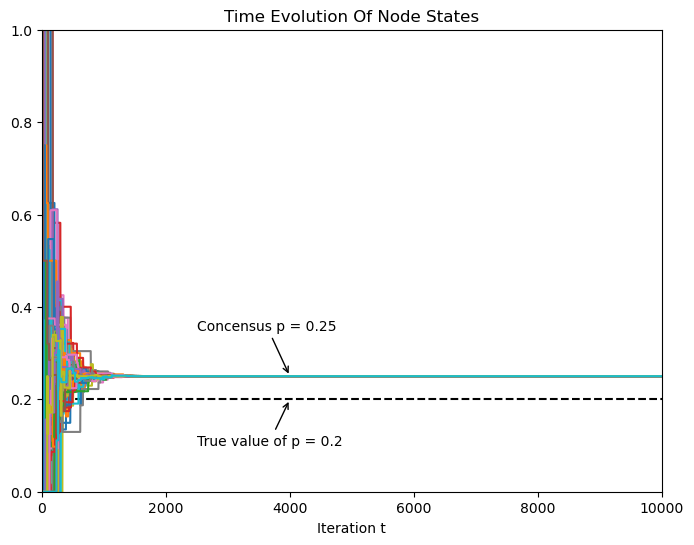

In [ ]:
fig = plt.figure(figsize = (8, 6))
ax = plt.gca()

t = [n for n in range(T+1)]

plt.axhline(p, color=(0, 0, 0, 1), linestyle='--')



concensus = x_hist[-1, 0]
if x_hist[-1, 0] - 0.1 > 0 and x_hist[-1, 0] < p:
    xytext = (2500, x_hist[-1, 0] - 0.1)
    ptext = (2500, p + 0.1)

elif x_hist[-1, 0] > p:
    xytext = (2500, x_hist[-1, 0] + 0.1)
    ptext = (2500, p - 0.1)
    
elif x_hist[-1, 0] - 0.1 < 0 and x_hist[-1, 0] < p:
    xytext = (2500, x_hist[-1, 0] + 0.05)
    ptext = (2500, p + 0.1)
    
ax.annotate(f"True value of p = {p}", xytext=ptext, xy=(4000, p),
            arrowprops=dict(arrowstyle="->"))
ax.annotate(f"Concensus p = {x_hist[-1, 0]:3g}", xytext=xytext, xy=(4000, x_hist[-1, 0]),
            arrowprops=dict(arrowstyle="->"))

for node in range(N):
    plt.plot(t, x_hist[:, node])

plt.xlim((0, T))
plt.ylim((0, 1))

plt.title('Time Evolution of Node States'.title())
plt.xlabel('Iteration t')
plt.ylabel('')
plt.show()

## Part 3

\begin{gather*}
\mathbb{E}\left[ W \right] = I - \frac{1}{|\mathcal{E}|} L
\end{gather*}

## Part 4

In [62]:
Wbar = np.eye(N) - 1/len(G.edges()) * nx.laplacian_matrix(G).toarray()
lambda2 = np.linalg.eig(Wbar)[0][1]
print(f"lambda_2(Wbar) = {lambda2:0.4f}")

lambda_2(Wbar) = 0.9848
